# Exercises

We have four exercises in this section:
1. Introduce normalization of features to kNN example
2. Rewrite the CART method to the Gini index.
3. Use pydot do draw the tree for C4.5 example.

## Exercise 1: Introduce normalization of features for kNN example

Normalize data features before applying kNN

In [1]:
import numpy as np
#import tensorflow_datasets as tfds
import pandas as pd
from math import sqrt
from sklearn.metrics import accuracy_score

# Construct a tf.data.Dataset
#ds = tfds.load('titanic', split='train', shuffle_files=True)
#titanic_df = tfds.as_dataframe(ds)

titanic_df = pd.read_csv("titanic-train.csv")
titanic_df.drop("Name", axis=1, inplace=True)
titanic_df.head()

columns = ['Survived','Age', 'Fare']
features = columns[1:]
titanic_df = titanic_df[columns].replace([np.inf, -np.inf], np.nan).dropna()

titanic_df = titanic_df[titanic_df['Fare'] > 30]

titanic_df

,Survived,Age,Fare
1,1,38.0,71.2833
3,1,35.0,53.1000
6,0,54.0,51.8625
9,1,14.0,30.0708
13,0,39.0,31.2750
...,...,...,...
853,1,16.0,39.4000
856,1,45.0,164.8667
867,0,31.0,50.4958
871,1,47.0,52.5542


### Normalize "Age" and "Fare" features here:

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
titanic_df[['Age', 'Fare']] = scaler.fit_transform(titanic_df[['Age', 'Fare']])

titanic_df.head()

,Survived,Age,Fare
1,1,0.348350,-0.213314
3,1,0.166654,-0.452113
6,0,1.317399,-0.468365
9,1,-1.105223,-0.754552
13,0,0.408916,-0.738738


### Check performance:

0.8


C:\Users\piotr\AppData\Local\Temp\ipykernel_7852\3926988464.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'black' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plot_test_set.loc[(plot_test_set["Survived"] == 1) & (plot_test_set["predicted"] == 0), "Survived"] = "black"


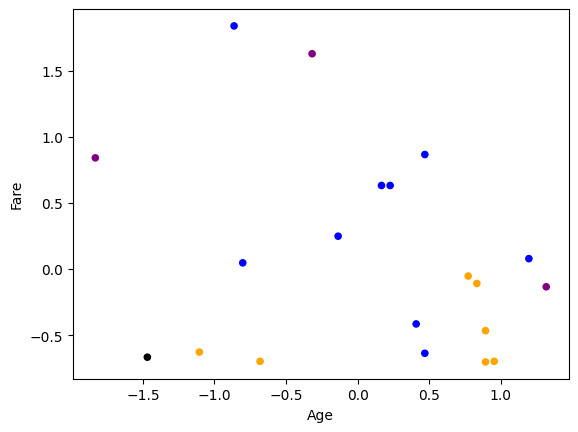

In [3]:
survivded_df = titanic_df[titanic_df['Survived']==1].sample(50, random_state=12345)
not_survivded_df = titanic_df[titanic_df['Survived']==0].sample(50, random_state=12345)

train_set = survivded_df.sample(40, random_state=12345)
train_set = pd.concat([train_set, not_survivded_df.sample(40, random_state=12345)])
plot_train_set = train_set
train_set_labels = train_set['Survived']
train_set = train_set[features]


test_set = survivded_df.sample(10, random_state=12345)
test_set = pd.concat([test_set, not_survivded_df.sample(10, random_state=12345)])
plot_test_set = test_set
test_set_labels = test_set['Survived']
test_set = test_set[features]

k = 5

def calculate_distance(x, v):
    """
    This method calculates the Euclidean distance between object x and v.

    :param x: first object
    :param v: second object
    :return: Euclidean distance
    """
    return sqrt((x[0] - v[0]) ** 2 + (x[1] - v[1]) ** 2)

def calculate_distance_matrix():
    """
    This method calculates the distance matrix between all objects.

    :return: A matrix of distances
    """    
    distance_matrix = np.zeros((len(data_set),len(data_set)))
    for i in range(len(data_set)):
        for j in range(len(data_set)):
            distance_matrix[i, j] = calculate_distance(data_set[i], data_set[j])
    return distance_matrix

def find_closest_objects(x, k):
    """
    Finds k closts objects to x.

    :return: A list of objects' ids.
    """        
    distances = []
    i = 0
    for item in train_set.values:
        distances.append([i, calculate_distance(x, item)])
        i = i + 1
    distances=np.array(distances)
    label_ids = distances[distances[:, 1].argsort()][:k,0]
    return [int(item) for item in label_ids]


def predict():
    """
    Assign a label of the most common label in the list of closest objects.

    :return: A list of predictions.
    """        
    predictions = []
    for item in test_set.values:
        label_ids = find_closest_objects(item, k)
        counts = np.bincount(train_set_labels.values[label_ids])
        label = np.argmax(counts)
        predictions.append(label)
    return predictions



predictions = predict()
acc = accuracy_score(predictions, test_set_labels)
print(acc)

plot_test_set['predicted'] = predictions

plot_test_set.loc[(plot_test_set["Survived"] == 1) & (plot_test_set["predicted"] == 0), "Survived"] = "black"
plot_test_set.loc[(plot_test_set["Survived"] == 1) & (plot_test_set["predicted"] == 1), "Survived"] = "blue"
plot_test_set.loc[(plot_test_set["Survived"] == 0) & (plot_test_set["predicted"] == 0), "Survived"] = "orange"
plot_test_set.loc[(plot_test_set["Survived"] == 0) & (plot_test_set["predicted"] == 1), "Survived"] = "purple"



res = plot_test_set.plot.scatter(x='Age',y='Fare',c='Survived').get_figure()

## Exercise 2: Rewrite the CART method to use Gini index as shown in the lecture

Use Gini index can be calculated with the following equation:
\begin{equation}
I_{G}(X)=1-\sum_{i=1}^{m}p^{2}_{i},
\end{equation}
and
\begin{equation}
I_{G}(\text{feature})=\sum_{i=1}^{n}p_{i}*I_{G}(X_{i}).
\end{equation}

You need to fill the ``calculate_gini`` function and change the ``build`` function a bit.

In [4]:
import math
import numpy as np
import pydot
import copy

class BinaryLeaf:

    def __init__(self, elements, labels, ids):
        self.L = None
        self.R = None
        self.elements = elements
        self.split_feature = None
        self.labels = labels
        self.completed = False
        self.ids = ids

    def set_R(self, Rleaf):
        self.R = Rleaf

    def set_L(self, Lleaf):
        self.L = Lleaf

    def set_elements(self, elements):
        self.elements = elements

    def get_elements(self):
        return self.elements

    def set_p(self, threshold):
        self.p = threshold

    def get_L(self):
        return self.L

    def get_R(self):
        return self.R

    def set_completed(self):
        self.completed = True

    def is_completed(self):
        return self.completed

    def get_labels(self):
        return self.labels

    def set_split(self, feature):
        self.split_feature = feature

    def get_split(self):
        return self.split_feature

    def set_ids(self, ids):
        self.ids = ids

    def get_ids(self):
        return self.ids

labels = [1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1]
data_set = [[1, 1, 2, 2], [2, 1, 2, 2], [1, 1, 1, 2], [1, 2, 1, 2], [2, 3, 2, 2],
            [2, 2, 1, 2], [3, 2, 2, 1], [1, 3, 2, 2], [3, 3, 2, 1], [2, 3, 1, 2],
            [3, 1, 1, 1], [1, 2, 1, 1], [2, 3, 1, 1], [2, 1, 1, 2], [2, 2, 1, 1]]


labels_count = len(np.unique(labels))

ids = list(range(len(data_set)))
root = BinaryLeaf(data_set, labels, ids)
current_node = root

## helper methods:

def get_unique_labels(labels):
    return np.unique(np.array(labels)).tolist()

def get_unique_values(elements):
    features_number = len(elements[0])
    unique = []
    for i in range(features_number):
        features_list = []
        for j in range(len(elements)):
            features_list.append(elements[j][i])
        unique.append(np.unique(np.array(features_list)))
    return unique

def is_leaf_completed(node):
    if node.is_completed():
        if node.get_L() != None and not node.get_L().is_completed():
            return node.get_L()
        elif node.get_R() != None and not node.get_R().is_completed():
            return node.get_R()
        elif node.get_L() == None and node.get_R() == None:
            return None
        elif node.get_L().is_completed() or node.get_R().is_completed():
            new_node = is_leaf_completed(node.get_L())
            if new_node == None:
                return is_leaf_completed(node.get_R())
            else:
                return new_node
        else:
            return None
    return node

def find_leaf_not_completed(root):
    return is_leaf_completed(root)


## CART methods:

def get_split_candidates(unique_values):
    split_list = []
    for i in range(len(unique_values)):
        current_list = []
        temp_list = copy.deepcopy(unique_values)
        current_list.append(temp_list[i])
        del temp_list[i]
        current_list.append(temp_list)
        split_list.append(current_list)
    return split_list


def get_number_of_labels_for_value(elements, column_id, label):
    count = 0
    if not isinstance(elements, list):
        elements_list = [elements]
    else:
        elements_list = elements

    column_elements = get_node_elements_column(column_id)

    for i in range(len(elements_list)):
        for j in range(len(column_elements)):
            if column_elements[j] == elements_list[i]:
                if current_node.labels[j] == label:
                    count = count + 1
    return count


def get_node_elements_column(column_id):
    return np.array(current_node.elements)[..., column_id].tolist()

def count_number_of_elements(elements, column_id):
    count = 0
    if isinstance(elements, list):
        column_elements = get_node_elements_column(column_id)
        for i in range(len(elements)):
            count = count + column_elements.count(elements[i])
    else:
        count = count + get_node_elements_column(column_id).count(elements)
    return count


# fill:
def calculate_gini(split_candidate, column_id):
    left_values = split_candidate[0]
    right_values = split_candidate[1]

    # liczba wszystkich elementów w aktualnym węźle
    total_count = len(current_node.labels)

    # liczba elementów po lewej i prawej stronie
    left_count = count_number_of_elements(left_values, column_id)
    right_count = count_number_of_elements(right_values, column_id)

    # zabezpieczenie
    if total_count == 0:
        return 1.0

    unique_labels = get_unique_labels(current_node.labels)

    def gini_for_group(group_values, group_count):
        if group_count == 0:
            return 0

        gini = 1
        for label in unique_labels:
            label_count = get_number_of_labels_for_value(group_values, column_id, label)
            p = label_count / group_count
            gini -= p ** 2
        return gini

    left_gini = gini_for_group(left_values, left_count)
    right_gini = gini_for_group(right_values, right_count)

    # ważona suma
    feature_gini = (left_count / total_count) * left_gini + (right_count / total_count) * right_gini

    return feature_gini
    

def check_completed(labels, elements):
    ratio = len(get_unique_labels(labels))
    if ratio == 1:
        return True
    elements = sorted(elements)
    duplicated = [elements[i] for i in range(len(elements)) if i == 0 or elements[i] != elements[i - 1]]
    if len(duplicated) == 1:
        return True
    return False

def split_node(current_node, value, split_id, split_history):
    left_leaf = []
    left_leaf_labels = []
    left_leaf_ids = []
    right_leaf = []
    right_leaf_labels = []
    right_leaf_ids = []
    for i in range(len(current_node.elements)):
        if current_node.elements[i][split_id] == value:
            left_leaf.append(current_node.elements[i])
            left_leaf_labels.append(current_node.labels[i])
            left_leaf_ids.append(current_node.ids[i])
        else:
            right_leaf.append(current_node.elements[i])
            right_leaf_labels.append(current_node.labels[i])
            right_leaf_ids.append(current_node.ids[i])
    if len(right_leaf_labels) == 0 or len(left_leaf_labels) == 0:
        current_node.set_completed()
        return current_node, split_history
    split_history.append([str(current_node.ids), str(left_leaf_ids)])
    split_history.append([str(current_node.ids), str(right_leaf_ids)])
    current_node.set_L(BinaryLeaf(left_leaf, left_leaf_labels, left_leaf_ids))
    current_node.set_R(BinaryLeaf(right_leaf, right_leaf_labels, right_leaf_ids))
    current_node.set_split(split_id)
    current_node.set_completed()
    if check_completed(left_leaf_labels, left_leaf):
        current_node.L.set_completed()
    if check_completed(right_leaf_labels, right_leaf):
        current_node.R.set_completed()
    return current_node, split_history

def get_current_node():
    return find_leaf_not_completed()


def build(root_node):
    global current_node
    current_node = root_node
    stop_criterion = False
    split_history = []

    while stop_criterion == False:
        unique_values = get_unique_values(current_node.get_elements())

        best_feature_id = None
        best_split_id = None
        best_gini = float('inf')

        for i in range(len(unique_values)):
            if len(unique_values[i]) == 1:
                continue

            split_candidates = get_split_candidates(unique_values[i].tolist())

            for j in range(len(split_candidates)):
                current_gini = calculate_gini(split_candidates[j], i)

                if current_gini < best_gini:
                    best_feature_id = i
                    best_split_id = j
                    best_gini = current_gini

        if best_feature_id is None:
            current_node.set_completed()
        else:
            current_node, split_history = split_node(
                current_node,
                unique_values[best_feature_id][best_split_id],
                best_feature_id,
                split_history
            )

        new_node = find_leaf_not_completed(root_node)
        if new_node is not None:
            current_node = new_node
        else:
            stop_criterion = True

    return root_node, split_history

def plot_tree(split_history):
    tree = pydot.Dot(graph_type='graph')
    for split in split_history:
        new_edge = pydot.Edge(split[0], split[1], fillcolor = 'red')
        tree.add_edge(new_edge)
    tree.write('cart_tree.png', format='png')


cart_tree, split_history = build(current_node)
plot_tree(split_history)

## Exercise 3: Use pydot do draw the tree for C4.5 example

Fill the code below.

In [5]:
import pickle
with open("c45_tree.pkl", "rb") as f:
    split_history_c45 = pickle.load(f)


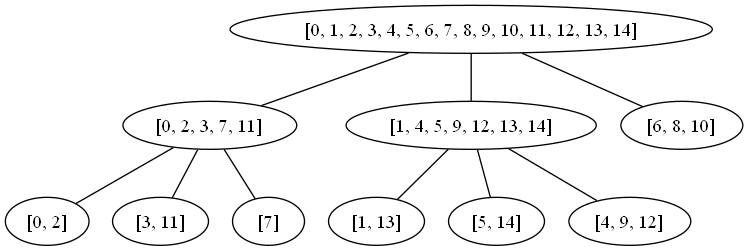

In [6]:
def plot_tree(split_history):
    tree = pydot.Dot(graph_type='graph')
    for split in split_history:
        new_edge = pydot.Edge(split[0], split[1], fillcolor='red')
        tree.add_edge(new_edge)
    tree.write('c45_tree.png', format='png')
    
plot_tree(split_history_c45)

from IPython.display import Image
Image(filename='c45_tree.png')